In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
iris=pd.read_csv('./datasets/iris.csv')
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               150 non-null    int64  
 1   sepal_length_cm  150 non-null    float64
 2   sepal_width_cm   150 non-null    float64
 3   petal_length_cm  150 non-null    float64
 4   petal_width_cm   150 non-null    float64
 5   species          150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [7]:
iris.head()

,id,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


Text(0.5, 1.0, 'Distribucion del ancho de sepalo de las flores')

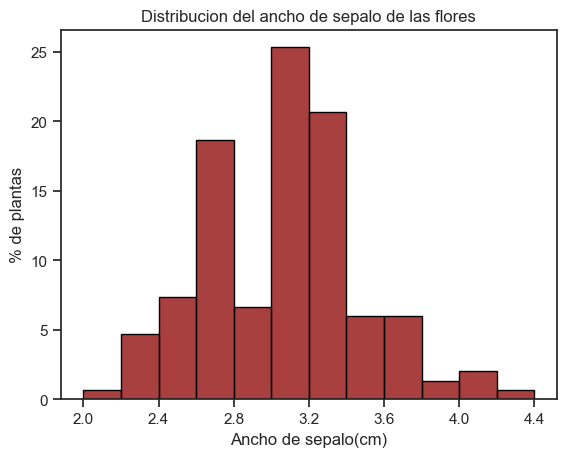

In [32]:
sns.set_theme(style='ticks')
ax = sns.histplot(x='sepal_width_cm',data=iris, stat='percent', color='darkred',edgecolor='black',bins=12) #stat='probability' para mostrar frecuencia relativa
ax.set_xticks([2., 2.4, 2.8, 3.2, 3.6, 4.0, 4.4])
plt.xlabel('Ancho de sepalo(cm)')
plt.ylabel('% de plantas')
plt.title('Distribucion del ancho de sepalo de las flores')


Text(0.5, 0, 'Largo del petalo(en cm)')

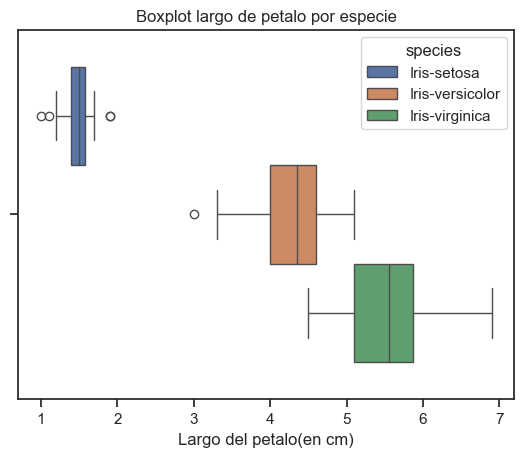

In [27]:
sns.boxplot(data=iris, x='petal_length_cm', hue='species')

plt.title('Boxplot largo de petalo por especie')
plt.xlabel('Largo del petalo(en cm)')

La iris virginica es la que tiene mayor mediana de largo de petalo, cerca a 5.5cm. LA versicolor esta cerca de 4.5cm y la setosa es la mas pequeña de 1.5cm aprox

Text(0.5, 0, 'Largo del petalo(en cm)')

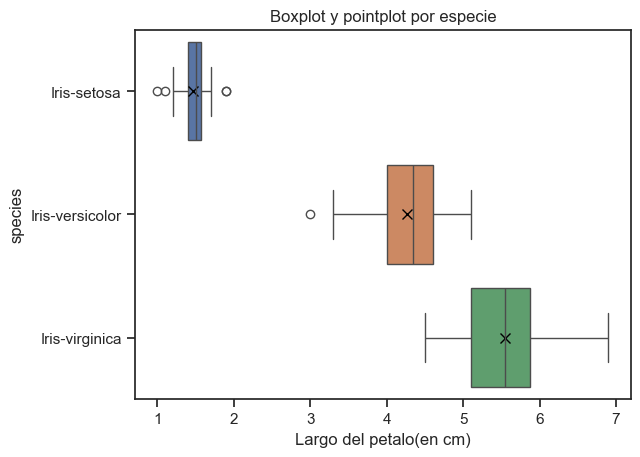

In [76]:
#fig,axes=plt.subplots(2,1,figsize=(5,10))
#sns.stripplot(data=iris, x='petal_length_cm', hue='species', y='species', jitter=0.2,ax=axes[0])
avg=iris.groupby('species')['petal_length_cm'].mean().reset_index()
sns.boxplot(data=iris, x='petal_length_cm', y='species',hue='species')
sns.pointplot(data=avg,x='petal_length_cm', y='species',hue='species',marker='x', markeredgecolor='black', markeredgewidth=1)

plt.title('Boxplot y pointplot por especie')
plt.xlabel('Largo del petalo(en cm)')


En el caso de la setosa y versicolor la media es menor a la mediana, mientras que en la virginica es practicamente igual. Las asimetrias son hacia la izquierda

In [79]:
avg=iris.groupby('species')['petal_length_cm'].mean().reset_index()
avg.head()

iris.groupby('species')['petal_length_cm'].describe()

,count,mean,std,min,25%,50%,75%,max
species,,,,,,,,
Iris-setosa,50.0,1.464,0.173511,1.0,1.4,1.50,1.575,1.9
Iris-versicolor,50.0,4.260,0.469911,3.0,4.0,4.35,4.600,5.1
Iris-virginica,50.0,5.552,0.551895,4.5,5.1,5.55,5.875,6.9


Text(0.5, 0, 'Ancho de petalo en cm')

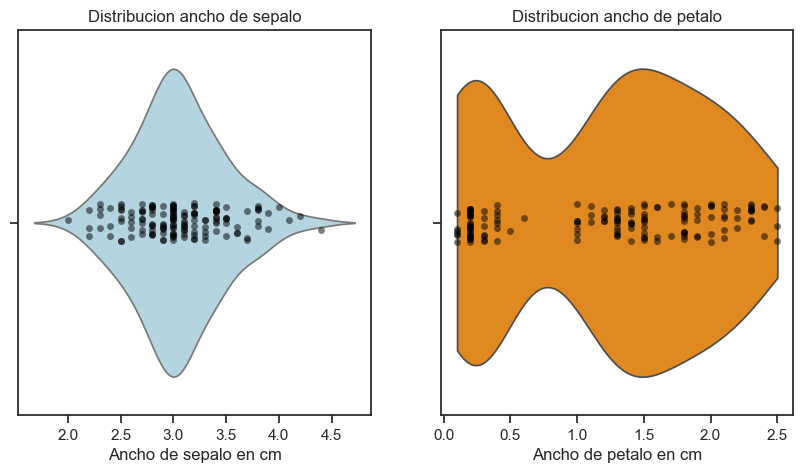

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(10,5))
sns.violinplot(x='sepal_width_cm', data=iris, ax=axes[0], color='lightblue', inner=None)
sns.stripplot(x='sepal_width_cm', data=iris, ax=axes[0], jitter=0.05, color='black', alpha=0.5)
sns.violinplot(x='petal_width_cm', data=iris, ax=axes[1], color='darkorange', inner=None, cut=0.3)
sns.stripplot(x='petal_width_cm', data=iris, ax=axes[1], jitter=0.05, color='black', alpha=0.5)

axes[0].set_title('Distribucion ancho de sepalo')
axes[0].set_xlabel('Ancho de sepalo en cm')
axes[1].set_title('Distribucion ancho de petalo')
axes[1].set_xlabel('Ancho de petalo en cm')

parece haber una relacion lineal entre ambas variables con un coeficiente de correlacion de pearson de 0.962757097050966.


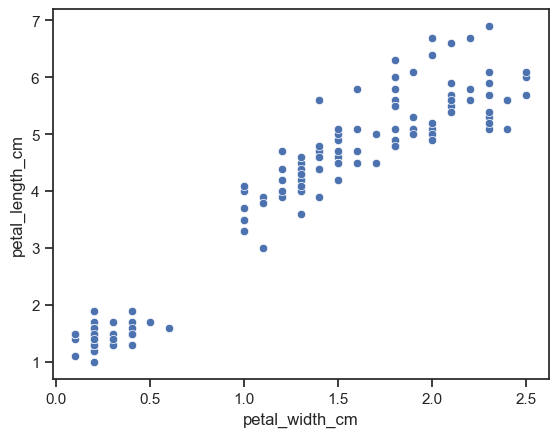

In [109]:
sns.scatterplot(data=iris, x='petal_width_cm', y='petal_length_cm')
corr = iris['petal_width_cm'].corr(iris['petal_length_cm'])

print(f'parece haber una relacion lineal entre ambas variables con un coeficiente de correlacion de pearson de {corr}.')